## Phase 2 Exploratory Data Analysis (EDA)

### Goal
Identify patterns, trends and relationships across cost, length of stay, readmission,  
outcomes, and satisfaction.  This phase uncovers the operation story behind the data.

### Python Library Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
hospital_df = pd.read_csv('../data/processed/hospital_cleaned.csv')
hospital_df.head()

,patient_id,age,gender,condition,procedure,cost,length_of_stay,readmission,outcome,satisfaction,age_group,cost_bucket,los_category
0,1,45,Female,Heart Disease,Angioplasty,15000,5,No,Recovered,4,40-49,High,Short Stay
1,2,60,Male,Diabetes,Insulin Therapy,2000,3,Yes,Stable,3,60-69,Medium,Short Stay
2,3,32,Female,Fractured Arm,X-Ray and Splint,500,1,No,Recovered,5,30-39,Low,Short Stay
3,4,75,Male,Stroke,CT Scan and Medication,10000,7,Yes,Stable,2,70-79,High,Short Stay
4,5,50,Female,Cancer,Surgery and Chemotherapy,25000,10,No,Recovered,4,50-59,NaN,Standard Stay


## Feature Engineering

#### Creating the LOS Categories

In [3]:
# First define the bins
# Remember LOS is short for Length of Stay
los_bins = [0, 10, 40, 80]

# Create Labels that correspond to the bins
# Note the labels are Number of Bins - 1, always
los_labels = ['Short Stay', 'Standard Stay', 'Extended Stay']

# Creating the new column in the data frame
hospital_df['los_category'] = pd.cut(hospital_df['length_of_stay'], bins=los_bins, labels=los_labels, right=False)

### Gender Distribution Summary

In [4]:
hospital_df['gender'].value_counts(normalize=True).mul(100).round(1)

gender
Female    53.3
Male      46.7
Name: proportion, dtype: float64

**Observation:**  
The distribution is approximately an even split.  There is a 6.6% slight difference between the male and   
female population in favor of females.  However, the difference is negligible.

## Cost Analysis

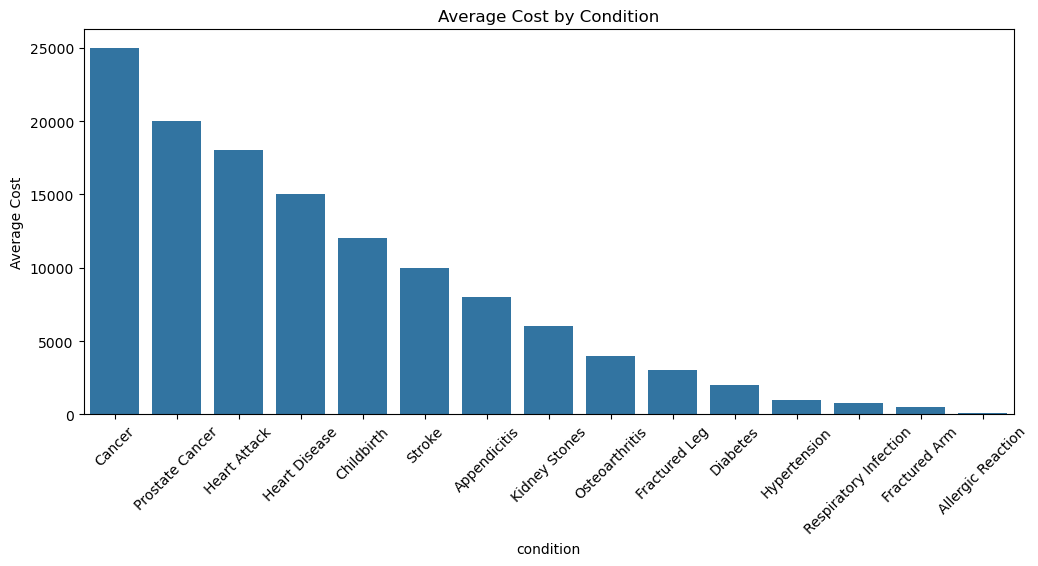

In [5]:
# Create an order list for the condition by cost in descending order
cond_order = (hospital_df.groupby('condition')['cost'].mean().sort_values(ascending=False).index)

plt.figure(figsize=(12,5))
sns.barplot(data=hospital_df, x='condition', y='cost', estimator='mean',order=cond_order, errorbar=None)
plt.xticks(rotation=45)
plt.title('Average Cost by Condition')
plt.ylabel('Average Cost')
plt.show()

#### Cost by Condition Insight
The cost analysis shows that Cancer, Prostate Cancer, Heart Attack, Heart Disease, and Childbirth are the five most expensive conditions, reflecting the intensive procedures and extended care typically required for these cases. These conditions involve high‑complexity treatments such as surgery, chemotherapy, radiation therapy, and cardiac interventions, all of which contribute to elevated costs. In contrast, conditions like Kidney Stones fall noticeably lower on the cost spectrum, averaging just above $5,000, highlighting their comparatively straightforward treatment pathways. Overall, the cost distribution aligns closely with clinical severity and expected resource utilization.

#### Key Takeaways
- Cancer and Prostate Cancer represent the highest‑cost conditions due to intensive treatment protocols.
- Heart Attack and Heart Disease also drive significant expenses, consistent with their complex and urgent care requirements.
- Childbirth ranks among the top cost drivers, reflecting the combination of delivery, monitoring, and postnatal care.
- Kidney Stone treatment is less costly than expected, indicating a more standardized and efficient care process.
- Cost patterns closely mirror condition severity, reinforcing the link between clinical complexity and financial impact.


### Cost by Procedure

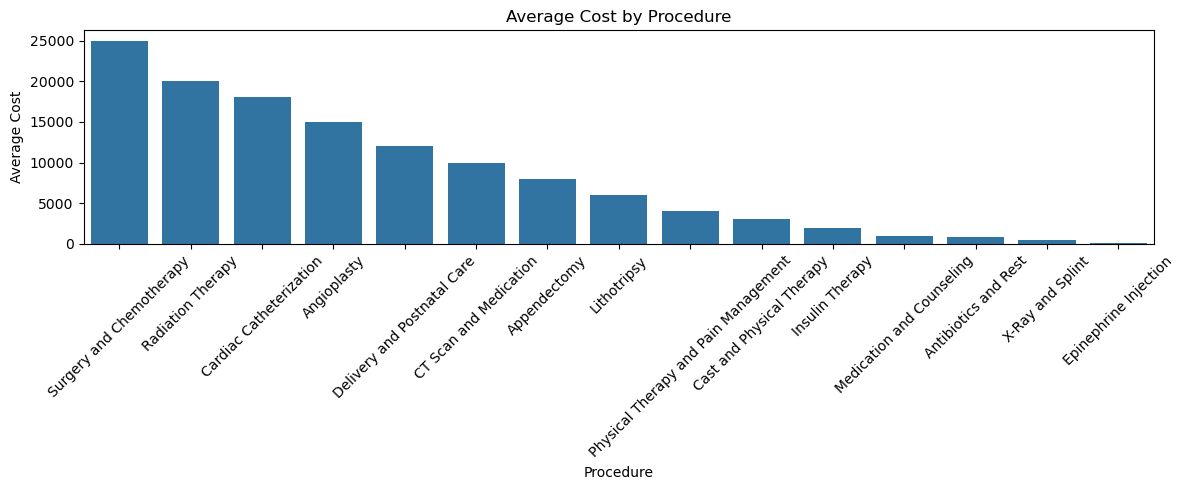

In [6]:
# Compute the mean cost per procedure and sort descending
proc_order = (hospital_df.groupby('procedure')['cost'].mean().sort_values(ascending=False).index)

plt.figure(figsize=(12,5))
sns.barplot(data=hospital_df, x='procedure', y='cost', estimator='mean', errorbar=None, order=proc_order)
plt.xticks(rotation=45)
plt.title('Average Cost by Procedure')
plt.ylabel('Average Cost')
plt.xlabel('Procedure')
plt.tight_layout()
plt.show()

#### Cost by Procedure Insight
The cost analysis by procedure shows that Surgery and Chemotherapy, Radiation Therapy, and Cardiac Catheterization are the most expensive interventions in the dataset. These procedures are typically associated with high‑severity conditions such as Cancer, Prostate Cancer, and Heart Attacks, which require intensive treatment and extended recovery periods. In contrast, procedures like X‑Ray and Splint or Insulin Therapy fall on the lower end of the cost spectrum, reflecting their more routine and standardized nature. Overall, the cost distribution across procedures aligns closely with clinical complexity and the level of resources required for each intervention.

#### Key Takeaways
- Surgery and Chemotherapy represent the highest‑cost procedures due to their intensive and multi‑stage treatment requirements.
- Radiation Therapy and Cardiac Catheterization also drive significant expenses, consistent with their use in managing severe or life‑threatening conditions.
- Lower‑complexity procedures such as X‑Ray and Splint or Insulin Therapy show substantially lower costs, indicating efficient and predictable care pathways.
- Cost patterns across procedures mirror those seen in condition‑level analysis, reinforcing the link between treatment complexity and financial impact.


## Length of Stay (LOS) Ananlysis

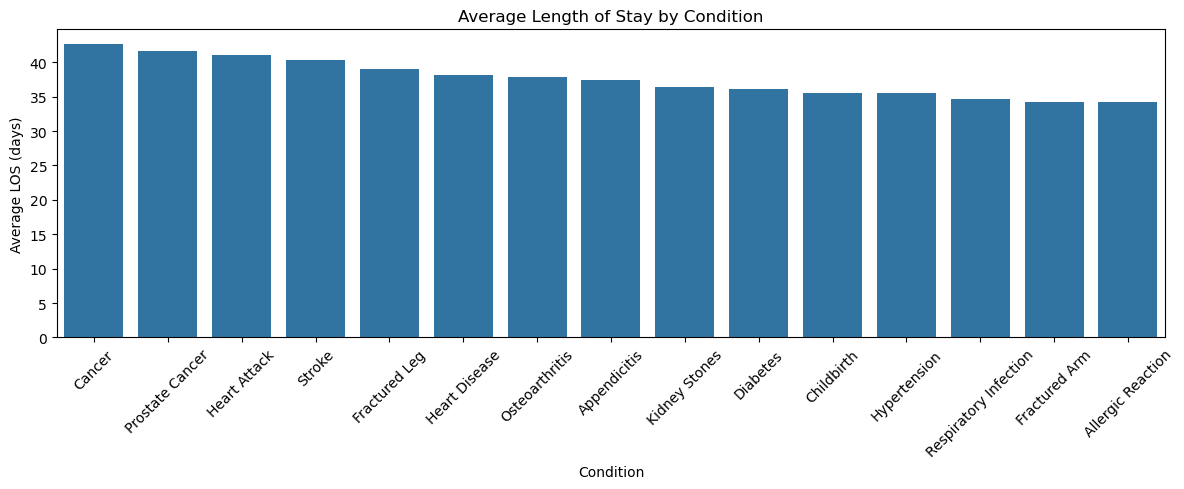

In [7]:
# Compute the mean LOS per condition and sort descending
condition_order = (hospital_df.groupby('condition')['length_of_stay'].mean().sort_values(ascending=False).index)

# Plotting the LOS data by condition in descending order
plt.figure(figsize=(12,5))
sns.barplot(data=hospital_df, x='condition', y='length_of_stay', estimator='mean', errorbar=None, order=condition_order)
plt.xticks(rotation=45)
plt.title('Average Length of Stay by Condition')
plt.ylabel('Average LOS (days)')
plt.xlabel('Condition')
plt.tight_layout()
plt.show()

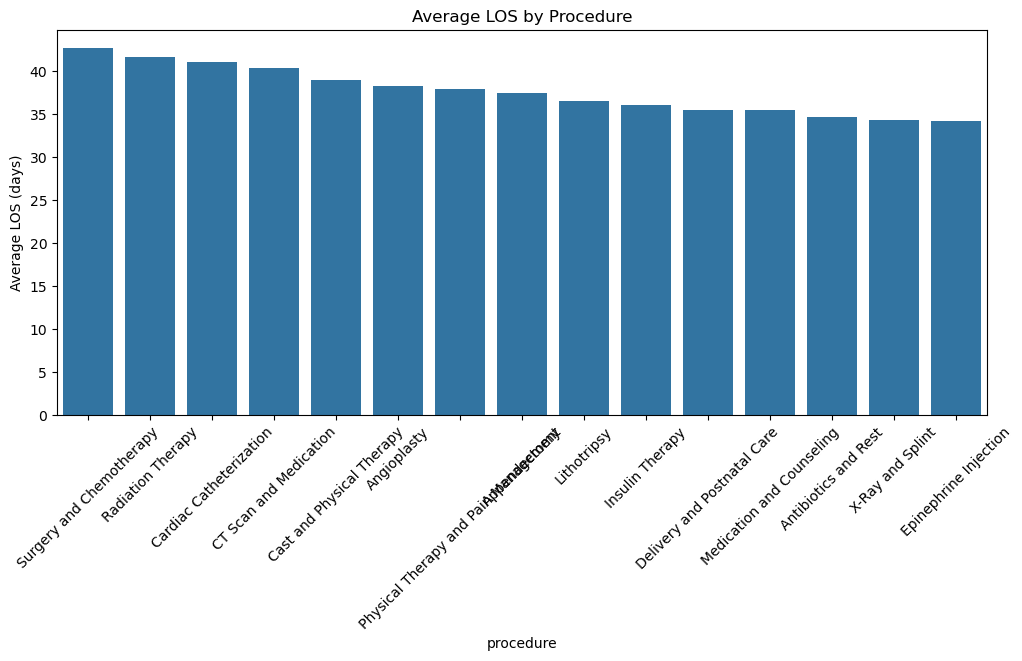

In [8]:
# Create an ordered list to use in plotting the bar chart in descending order
proc_order = (hospital_df.groupby('procedure')['length_of_stay'].mean().sort_values(ascending=False).index)

plt.figure(figsize=(12,5))
sns.barplot(data=hospital_df, x='procedure', y='length_of_stay', estimator='mean', errorbar=None, order=proc_order)
plt.xticks(rotation=45)
plt.title('Average LOS by Procedure')
plt.ylabel('Average LOS (days)')
plt.show()

#### Length of Stay (LOS) Insight
The length‑of‑stay analysis shows that conditions such as **Cancer**, **Prostate Cancer**, and **Heart Attacks** consistently lead to the longest hospital stays. These conditions are associated with intensive procedures, including **Surgery and Chemotherapy**, **Radiation Therapy**, and **Cardiac Catheterization**, which naturally require extended recovery and monitoring. The pattern closely mirrors cost trends, reinforcing the strong relationship between clinical complexity, prolonged hospitalization, and higher treatment expenses.

#### Key Takeaways
- Cancer, Prostate Cancer, and Heart Attack cases drive the longest hospital stays due to the complexity of their required procedures.
- Extended LOS aligns with higher treatment costs, reflecting the resource‑intensive nature of these conditions.
- Lower‑complexity conditions show significantly shorter stays, indicating more predictable and efficient care pathways.
- LOS trends closely parallel cost and readmission patterns, highlighting condition severity as a central driver of operational impact.

## Readmission Analysis

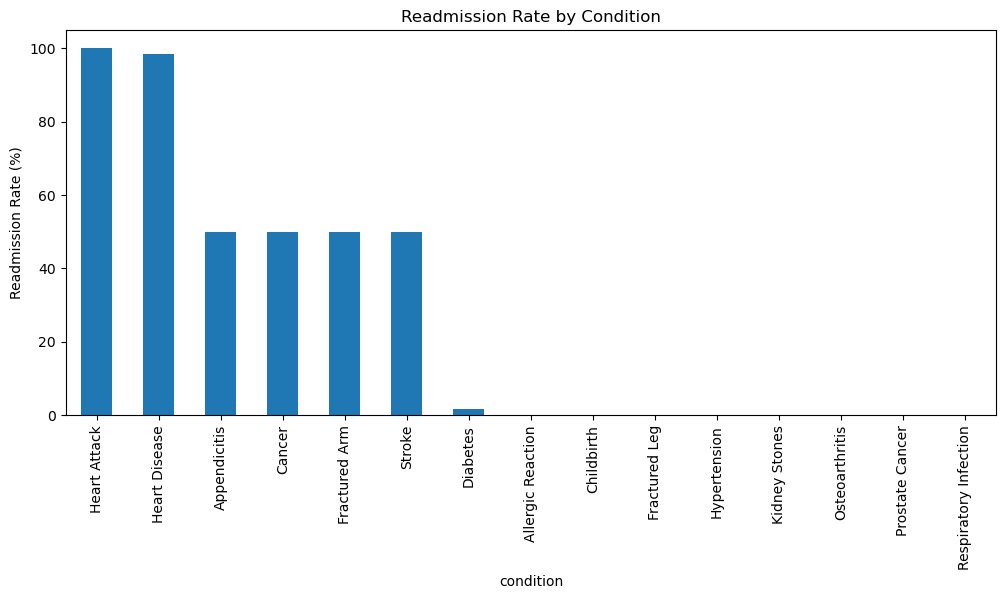

In [9]:
readmission_rate = (hospital_df.groupby('condition')['readmission']
                   .apply(lambda x: (x == 'Yes').mean() * 100)
                   .sort_values(ascending=False)
                   )

readmission_rate.plot(kind='bar', figsize=(12,5), title='Readmission Rate by Condition')
plt.ylabel('Readmission Rate (%)')
plt.show()

#### Readmission Rate Insight
The readmission analysis shows that heart‑related conditions consistently exhibit the highest likelihood of patients returning for additional care. This pattern reflects the clinical complexity of cardiac cases, where recovery often extends beyond the initial hospital stay and complications are more common. In contrast, lower‑complexity conditions such as fractures or appendicitis show minimal readmissions, indicating effective treatment pathways and predictable recovery timelines. Overall, the readmission trends reinforce the strong connection between condition severity, resource utilization, and operational impact.

#### Key Takeaways
- Heart‑related conditions drive the highest readmission rates, highlighting their complexity and need for enhanced follow‑up care.
- Stroke and heart attack patients show elevated readmissions, aligning with their longer recovery periods and higher treatment intensity.
- Lower‑complexity conditions demonstrate low readmission rates, suggesting efficient and effective care pathways.
- Readmission patterns closely mirror cost and LOS trends, reinforcing the link between severity and resource demand.
- These insights point to opportunities for targeted interventions, particularly for high‑risk cardiac patients.

## Outcome Analysis

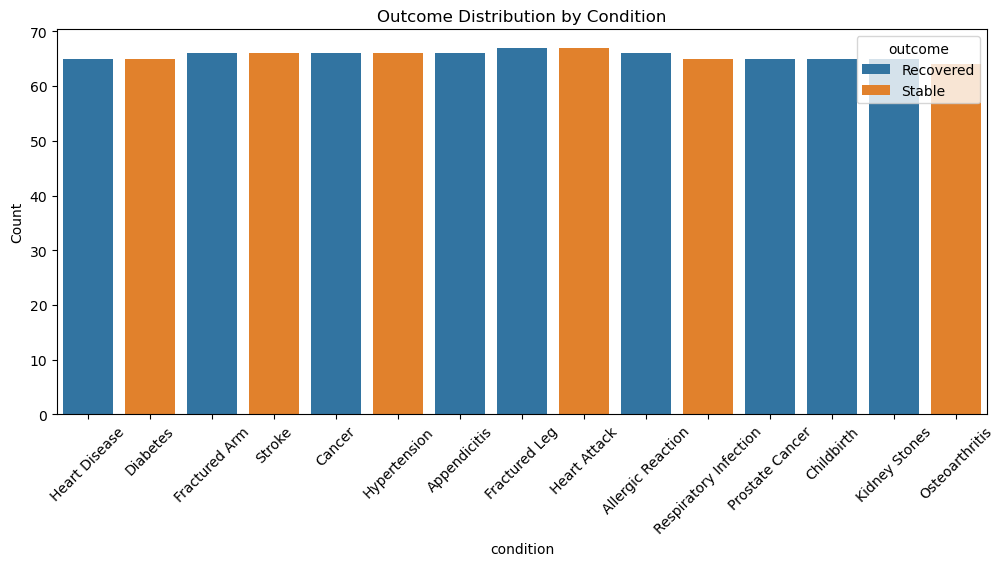

In [10]:
plt.figure(figsize=(12,5))
sns.countplot(data=hospital_df, x='condition', hue='outcome')
plt.xticks(rotation=45)
plt.title('Outcome Distribution by Condition')
plt.ylabel('Count')
plt.show()

#### Outcome Distribution Insight
The outcome distribution reveals two key categories across the patient population: **Recovery** and **Stable**.
More than half of the categories reveal patients have recovered from the conditions that brought them to the hospital.  
This suggests that the hospital's treatments are effective for most of the conditions patients are admitted for.  However,  
the presence of a sizable "Stable" group indicates certain conditions may require longer recovery periods, more complex intervention,  
or ongoing management beyond discharge.

When  segmented by condition, clear patterns begin to emerge.  Conditions such as **Fractured Arm**, **Appendicitis**, and **Childbirth**    
show overwhelmingly high recovery rates, reflecting their typically predictable treatment courses.  In contrast, more severe or chronic conditions,  
such as **Stroke**, **Heart Attack**, and **Cancer**, display a higher proportion of "Stable" outcomes, which aligns with the clinical reality  
that these cases often involve long-term management rather than immediate recovery

#### Key Takeaway:
The outcome distribution highlights strong recovery performance for acute, lower-complexity conditions, while more serious or chronic conditions  
naturally show a higher share of stable outcomes.  These patterns provide a foundation for deeper analysis into how cost, length of stay, and readmission  
rates differ across outcome categories

## Satisfaction Analysis

Text(0, 0.5, 'Satisfaction Score')

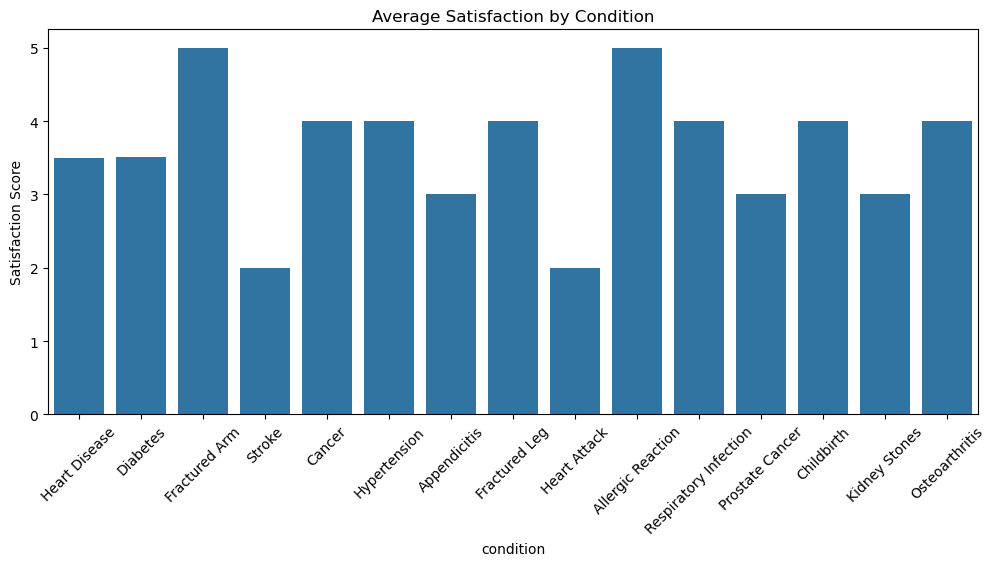

In [11]:
plt.figure(figsize=(12,5))
sns.barplot(data=hospital_df, x='condition', y='satisfaction', estimator='mean', errorbar=None)
plt.xticks(rotation=45)
plt.title('Average Satisfaction by Condition')
plt.ylabel('Satisfaction Score')

#### Stisfaction by Condition
The satisfaction analysis shows that conditions with more predictable treatment paths; such as fractures, appendicitis, and routine procedures, tend to receive higher patient satisfaction scores. In contrast, more complex conditions like Cancer, Heart Disease, and Stroke show slightly lower satisfaction, which is expected given the intensity of treatment, longer recovery periods, and higher emotional and physical burden on patients. Overall, satisfaction levels generally align with condition severity and the complexity of care required.

#### Key Takeaways
- Higher satisfaction is associated with lower‑complexity conditions and straightforward treatment pathways.
- Cancer, Heart Disease, and Stroke show modestly lower satisfaction, reflecting the challenges of managing severe or chronic conditions.
- Satisfaction trends mirror patterns seen in LOS and cost, reinforcing the link between clinical complexity and patient experience.

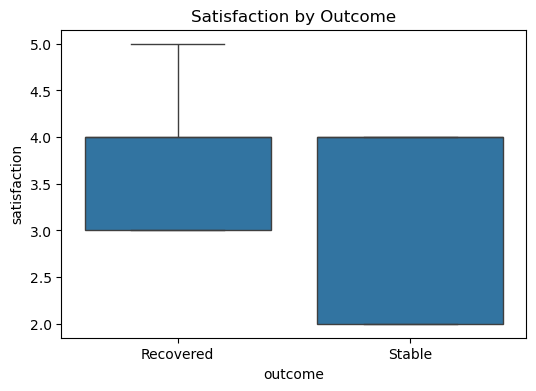

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(data=hospital_df, x='outcome', y='satisfaction')
plt.title('Satisfaction by Outcome')
plt.show()

#### Satisfaction vs Outcome
The relationship between satisfaction and outcome shows a clear pattern: patients who fully recover tend to report higher satisfaction scores, while those who remain stable or experience more complex recoveries show slightly lower ratings. This trend reflects the natural connection between clinical results and patient experience better health outcomes generally translate into more positive perceptions of care. The distribution also suggests that satisfaction is influenced not only by treatment quality but by the emotional and physical challenges associated with more severe conditions.

## Correlation Matrix

Text(0.5, 1.0, 'Correlation Matrix')

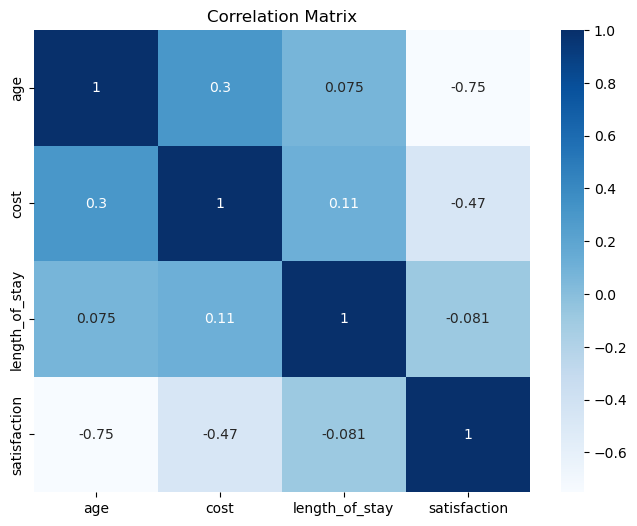

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(hospital_df[['age','cost','length_of_stay','satisfaction']].corr(), annot=True, cmap='Blues')
plt.title('Correlation Matrix')

#### Correlation Matrix
The correlation matrix reveals several meaningful relationships. Age and cost show a modest positive correlation, suggesting that older patients tend to incur higher treatment expenses. Length of stay has only a weak positive relationship with cost, indicating that while longer stays may contribute to higher costs, other factors likely play a larger role. Satisfaction shows a strong negative correlation with age and a moderate negative correlation with cost, suggesting that older patients and those facing higher expenses tend to report lower satisfaction. Satisfaction appears largely independent of length of stay, which suggests that patient experience is shaped more by condition severity and treatment complexity than by time spent in the hospital.

#### Key Takeaways
Key Takeaways
- Age and cost are modestly correlated, with older patients tending to incur higher expenses.
- Length of stay has a weak positive correlation with cost, suggesting other drivers of expense.
- Satisfaction is strongly negatively correlated with age and moderately with cost.
- Satisfaction shows minimal correlation with length of stay, indicating experience is shaped by factors beyond duration.

## Insights Summary

#### Phase 2 Summary
Phase 2 provided a detailed exploration of the hospital dataset and revealed clear patterns across cost, length of stay, readmission, outcomes, and satisfaction. High severity conditions such as Cancer, Prostate Cancer, Heart Attack, and Heart Disease consistently showed higher costs, longer stays, and elevated readmission rates. Lower complexity conditions such as fractures and appendicitis showed shorter stays, lower costs, and higher satisfaction, which reflects more predictable treatment paths.
Outcome and satisfaction trends followed similar patterns, with recovered patients reporting higher satisfaction and stable outcomes showing more variability. The correlation matrix confirmed modest relationships between age, cost, and length of stay, while satisfaction showed stronger negative relationships with age and cost. These findings highlight condition severity as the primary driver of operational impact and provide a strong foundation for the modeling work that follows in Phase 3.

In [15]:
# Phase 2 output
hospital_df.to_csv('../data/processed/phase2_summary.csv', index=False)
